In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def slq_linear(matvec,
               dim,
               num_probes=10,
               num_iters=50,
               dtype=torch.float32,
               device='cpu'):
    """
    Stochastic Lanczos Quadrature for a Hermitian linear operator.

    Args:
      matvec    : a function v (dim,) -> A @ v  (dim,)
      dim       : dimension of the ambient space D
      num_probes: number of random Lanczos runs
      num_iters : maximum Lanczos steps per run
      dtype     : torch dtype
      device    : device for all torch work

    Returns:
      eigen_list  : list of length num_probes; each is an np.ndarray of length ≤ num_iters 
      weight_list : list of length num_probes; each is an np.ndarray of same length
    """
    eigen_list_full  = []
    weight_list_full = []

    for k in range(num_probes):
        # 1) Draw a normalized Rademacher probe
        v = torch.randint(0, 2, (dim,), device=device, dtype=dtype)
        v[v==0] = -1
        v = v / (v.norm() + 1e-12)

        alphas = []
        betas  = []
        vs     = [v]

        # Alg 10.3.1
        for j in range(num_iters):
            v_j = vs[-1]
            w = matvec(v_j)            # w = H v_j
            alpha = torch.dot(v_j, w)
            alphas.append(alpha.item())

            # Orthogonalize
            w = w - alpha * v_j
            if j > 0:
                w = w - betas[-1] * vs[-2]

            beta = w.norm().item()
            betas.append(beta)
            if beta < 1e-14:
                break   

            v_next = w / (beta + 1e-12)
            vs.append(v_next)

        m = len(alphas)
        # build tridiagonal T
        T = torch.zeros((m, m), dtype=dtype, device=device)
        for i in range(m):
            T[i,i] = alphas[i]
            if i < m-1:
                T[i,i+1] = betas[i]
                T[i+1,i] = betas[i]

        # eigendecompose T
        eigvals, eigvecs = torch.linalg.eigh(T)
        eigvals = eigvals.cpu().numpy()
        # weight = square of the first component of each eigenvector
        w0 = (eigvecs[0,:].cpu().numpy())**2

        eigen_list_full.append(eigvals)
        weight_list_full.append(w0)

    return eigen_list_full, weight_list_full

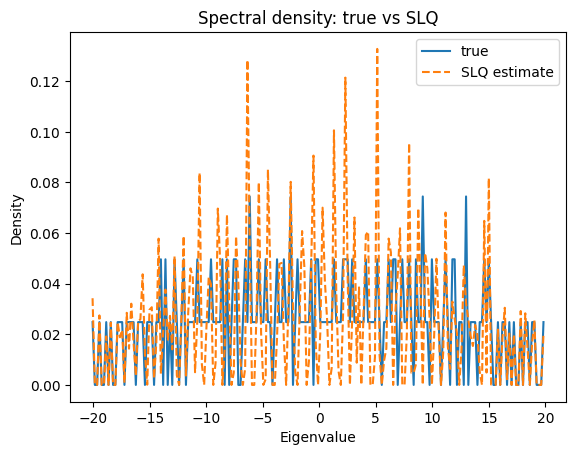

In [7]:
torch.manual_seed(0)

# 1) build a random symmetric matrix A
n = 200
M = torch.randn(n,n)
A = (M + M.t()) / 2.0
A = A.to(torch.float32)

# 2) define the matvec function
def matvec(v):
    return A.matmul(v)

# 3) run SLQ
num_probes = 20
num_iters  = 60
eigs_list, wts_list = slq_linear(
    matvec,
    dim=n,
    num_probes=num_probes,
    num_iters=num_iters,
    dtype=A.dtype,
    device=A.device
)

# 4) form a histogram / density estimate
all_eigs = np.hstack(eigs_list)
all_wts  = np.hstack(wts_list)

# true eigenvalues
true_eigs = torch.linalg.eigvalsh(A).cpu().numpy()

# bins for density
bins = np.linspace(min(all_eigs.min(), true_eigs.min()),
                   max(all_eigs.max(), true_eigs.max()),
                   200)
hist_slq = np.zeros(len(bins)-1)
# accumulate SLQ weights
for eigs, wts in zip(eigs_list, wts_list):
    idx = np.searchsorted(bins, eigs) - 1
    for i, w in zip(idx, wts):
        if 0 <= i < len(hist_slq):
            hist_slq[i] += w
hist_slq /= (num_probes * (bins[1] - bins[0]))

# true density via plain histogram
hist_true, _ = np.histogram(true_eigs, bins=bins, density=True)

# plot
x = 0.5*(bins[:-1] + bins[1:])
plt.plot(x, hist_true, label="true")
plt.plot(x, hist_slq, label="SLQ estimate", linestyle="--")
plt.legend()
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Spectral density: true vs SLQ")
plt.show()

In [36]:
 def demo_wishart_slq(n=200, m=400, num_probes=20, num_iters=60, seed=0):
    torch.manual_seed(seed)
    device = 'cpu'
    dtype  = torch.float32

    # Generate X ∈ ℝⁿˣᵐ with N(0,1) entries
    X = torch.randn(n, m, device=device, dtype=dtype)
    # Build the normalized Wishart W = (1/m) X Xᵀ
    W = (1.0/m) * (X @ X.t())

    # Define the matvec function for SLQ
    def matvec(v):
        return W.matmul(v)

    # Run SLQ
    eigs_list, wts_list = slq_linear(
        matvec   = matvec,
        dim      = n,
        num_probes = num_probes,
        num_iters  = num_iters,
        dtype    = dtype,
        device   = device
    )

    # Flatten out all Ritz values and weights
    all_r = np.hstack(eigs_list)
    all_w = np.hstack(wts_list)

    # Compute an empirical histogram from the SLQ output
    nbins = 200
    bins = np.linspace(all_r.min(), all_r.max(), nbins+1)
    hist_slq = np.zeros(nbins)
    for r, w in zip(all_r, all_w):
        idx = np.searchsorted(bins, r) - 1
        if 0 <= idx < nbins:
            hist_slq[idx] += w
    # normalize by (#probes)*(bin width)
    hist_slq /= (num_probes * (bins[1]-bins[0]))

    # (Optional) True eigenvalues for small n, to compare
    true_eigs = torch.linalg.eigvalsh(W).cpu().numpy()
    hist_true, _ = np.histogram(true_eigs, bins=bins, density=True)

    # ----------------------------------------
    # 3) Marchenko–Pastur density
    # ----------------------------------------
    c = n / m
    lambda_min = (1 - np.sqrt(c))**2
    lambda_max = (1 + np.sqrt(c))**2

    x = np.linspace(lambda_min, lambda_max, 1000)
    mp_density = np.sqrt((lambda_max - x)*(x - lambda_min)) / (2*np.pi*c*x)
    mp_density[np.isnan(mp_density)] = 0.0

    # ----------------------------------------
    # 4) Plot everything
    # ----------------------------------------
    bin_centers = 0.5*(bins[:-1] + bins[1:])
    plt.figure(figsize=(8,5))
    plt.plot(bin_centers, hist_slq, label="SLQ estimate", lw=2)
    plt.plot(x, mp_density, label="Marchenko–Pastur density", lw=2, linestyle='--')
    plt.plot(bin_centers, hist_true, label="True histogram", lw=1, alpha=0.6)
    plt.xlim(lambda_min*0.9, lambda_max*1.1)
    plt.ylim(0, max(hist_slq.max(), mp_density.max())*1.1)
    plt.xlabel("Eigenvalue")
    plt.ylabel("Density")
    plt.title(f"Wishart(n={n},m={m}), c={c:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

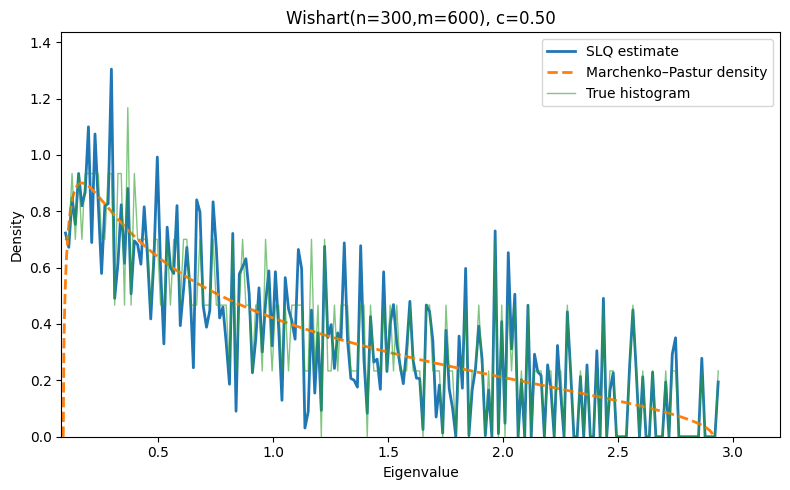

In [37]:
demo_wishart_slq(
    n=300,    # dimension of W
    m=600,    # rank of X
    num_probes=30,
    num_iters=200,
    seed=123
)

In [3]:
def slq_hessian(model,
                loss_fn,
                inputs,
                targets,
                num_probes=10,
                num_iters=50,
                cuda=True):
    """
    Estimate the Hessian spectral density via SLQ.

    Args:
      model     : a torch.nn.Module in eval() mode
      loss_fn   : a loss function, e.g. nn.CrossEntropyLoss()
      inputs    : a single batch of inputs (or the entire dataset if small)
      targets   : corresponding labels
      num_probes: SLQ probes
      num_iters : Lanczos iterations
      cuda      : whether to move everything to GPU

    Returns:
      eigen_list, weight_list: same format as slq_linear
    """
    device = 'cuda' if cuda else 'cpu'
    model  = model.to(device).eval()
    inputs = inputs.to(device)
    targets= targets.to(device)

    # 1) forward + get gradient w.r.t. params
    model.zero_grad()
    outputs = model(inputs)
    loss    = loss_fn(outputs, targets)
    # create_graph=True so we can do a second‐order derivative
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)

    

    # Flatten parameter list to a single vector of dimension D
    params   = [p for p in model.parameters() if p.requires_grad]
    D        = sum(p.numel() for p in params)

    # Store the "first derivatives" in a list so that we can do a second‐order
    # torch.autograd.grad call for Hv
    grads_list = list(grads)

    def hvp(v_flat):
        """
        Given v_flat of shape (D,), produce H @ v_flat also of shape (D,)
        """
        # un‐flatten v_flat back into a list of tensors matching params
        v_list = []
        offset = 0
        for p in params:
            n = p.numel()
            v_list.append( v_flat[offset:offset+n].view_as(p) )
            offset += n

        # compute Hv by feeding v_list into a second grad
        hv_list = torch.autograd.grad(
            grads_list,
            params,
            grad_outputs=v_list,
            retain_graph=True,
            create_graph=False
        )

        # [h.contiguous() for h in hv_list]
        # flatten back to a single vector
        hv_flat = torch.cat([h.reshape(-1) for h in hv_list])
        return hv_flat

    # Build an initial flattened grads vector just to fix dtype & device
    dummy_v = torch.randn(D, device=device, dtype=params[0].dtype)

    # Call the generic SLQ on H via hvp
    eigen_list, weight_list = slq_linear(
        matvec = hvp,
        dim    = D,
        num_probes=num_probes,
        num_iters =num_iters,
        dtype= dummy_v.dtype,
        device=dummy_v.device
    )

    del grads, grads_list
    torch.cuda.empty_cache()

    return eigen_list, weight_list


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def get_esd_plot(eigenvalues, weights):
    density, grids = density_generate(eigenvalues, weights)
    plt.semilogy(grids, density + 1.0e-7)
    plt.ylabel('Density (Log Scale)', fontsize=14, labelpad=10)
    plt.xlabel('Eigenvlaue', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.axis([np.min(eigenvalues) - 1, np.max(eigenvalues) + 1, None, None])
    plt.tight_layout()
    plt.show()
    plt.savefig('example.pdf')


def density_generate(eigenvalues,
                     weights,
                     num_bins=10000,
                     sigma_squared=1e-5,
                     overhead=0.01):

    eigenvalues = np.array(eigenvalues)
    weights = np.array(weights)

    lambda_max = np.mean(np.max(eigenvalues, axis=1), axis=0) + overhead
    lambda_min = np.mean(np.min(eigenvalues, axis=1), axis=0) - overhead

    grids = np.linspace(lambda_min, lambda_max, num=num_bins)
    sigma = sigma_squared * max(1, (lambda_max - lambda_min))

    num_runs = eigenvalues.shape[0]
    density_output = np.zeros((num_runs, num_bins))

    for i in range(num_runs):
        for j in range(num_bins):
            x = grids[j]
            tmp_result = gaussian(eigenvalues[i, :], x, sigma)
            density_output[i, j] = np.sum(tmp_result * weights[i, :])
    density = np.mean(density_output, axis=0)
    normalization = np.sum(density) * (grids[1] - grids[0])
    density = density / normalization
    return density, grids


def gaussian(x, x0, sigma_squared):
    return np.exp(-(x0 - x)**2 /
                  (2.0 * sigma_squared)) / np.sqrt(2 * np.pi * sigma_squared)


In [5]:
from pytorchcv.model_provider import get_model as ptcv_get_model # model
import torch, torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torch import nn

#get the model 
model = ptcv_get_model("resnet20_cifar10", pretrained=True)
# change the model to eval mode to disable running stats upate
model.eval()

loss_fn= torch.nn.CrossEntropyLoss()

# 1) CIFAR-10 transforms & dataset
transform = T.Compose([
    T.ToTensor(),
    # CIFAR-10 mean/std
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616))
])


# train=False or True, doesn’t matter for a single batch
dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 2) DataLoader and grab first batch
loader = DataLoader(dataset,
                    batch_size=100,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

inputs, targets = next(iter(loader))


In [6]:
import torch.nn.functional as F
from torchvision import datasets, transforms

def getData(name='cifar10', train_bs=128, test_bs=1000):
    """
    Get the dataloader
    """
    if name == 'cifar10':
        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])

        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])

        trainset = datasets.CIFAR10(root='../data',
                                    train=True,
                                    download=True,
                                    transform=transform_train)
        train_loader = torch.utils.data.DataLoader(trainset,
                                                   batch_size=train_bs,
                                                   shuffle=True)

        testset = datasets.CIFAR10(root='../data',
                                   train=False,
                                   download=False,
                                   transform=transform_test)
        test_loader = torch.utils.data.DataLoader(testset,
                                                  batch_size=test_bs,
                                                  shuffle=False)
    if name == 'cifar10_without_dataaugmentation':
        transform_train = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])

        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])

        trainset = datasets.CIFAR10(root='../data',
                                    train=True,
                                    download=True,
                                    transform=transform_train)
        train_loader = torch.utils.data.DataLoader(trainset,
                                                   batch_size=train_bs,
                                                   shuffle=True)

        testset = datasets.CIFAR10(root='../data',
                                   train=False,
                                   download=False,
                                   transform=transform_test)
        test_loader = torch.utils.data.DataLoader(testset,
                                                  batch_size=test_bs,
                                                  shuffle=False)

    return train_loader, test_loader

In [7]:
train_loader, test_loader = getData()
inputs, targets = next(iter(train_loader))

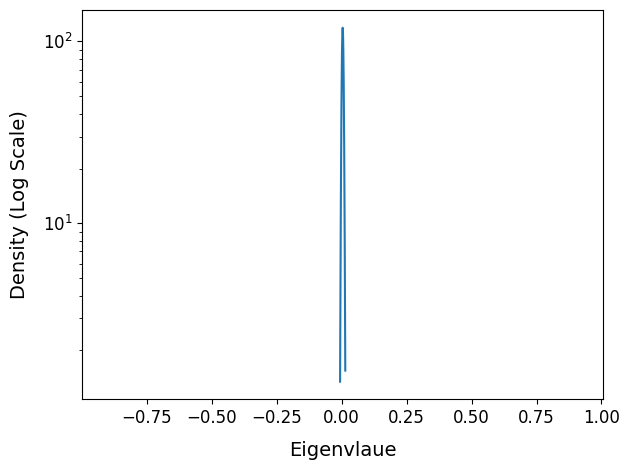

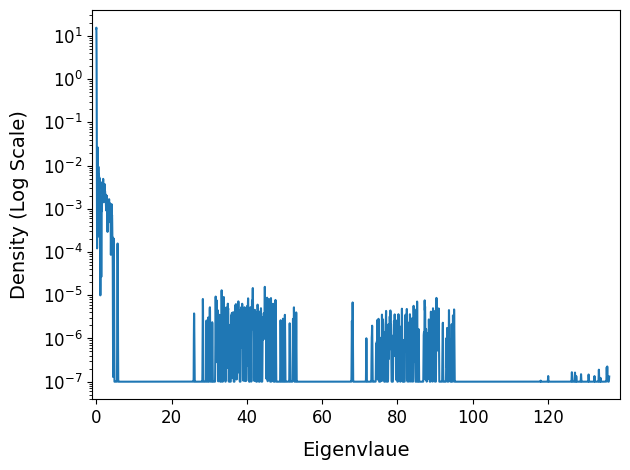

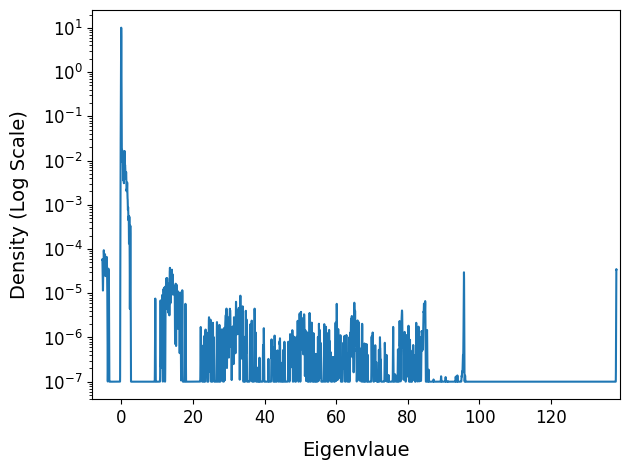

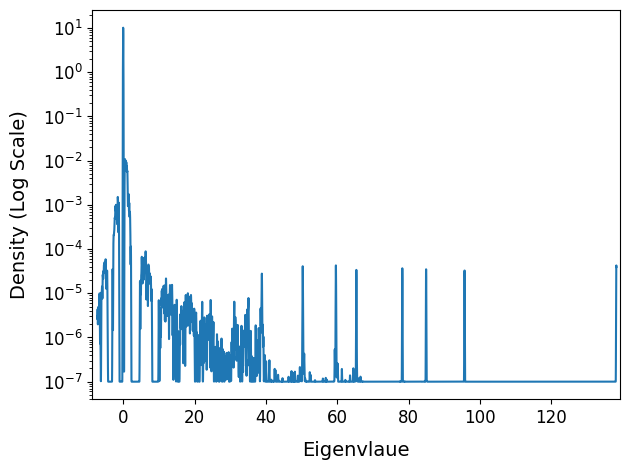

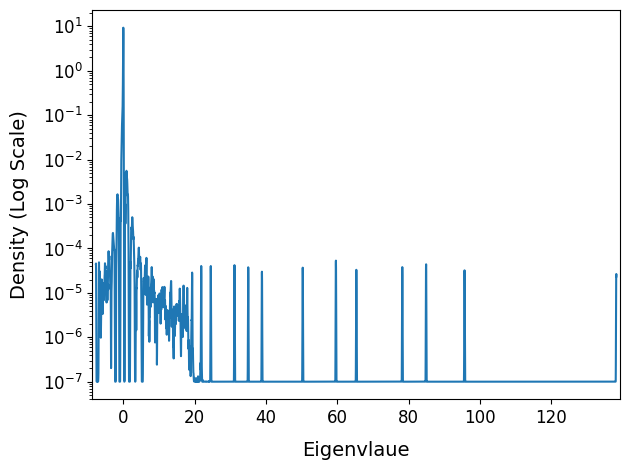

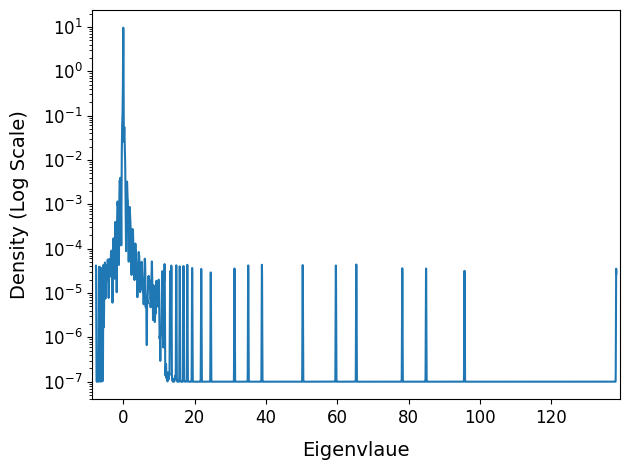

<Figure size 640x480 with 0 Axes>

In [14]:
for n_iters in [1, 5, 10, 20, 50, 100] :
    eigs_list, wts_list = slq_hessian(
        model, loss_fn, inputs, targets,
        num_probes=100,
        num_iters=n_iters,
        cuda=torch.cuda.is_available()
    )
    get_esd_plot(eigs_list, wts_list)